# Next steps: interpretable multiclass modeling


## Notebook roadmap

1. Load the joined dataset  
2. Inspect class balance of `click`, `basket`, `order`  
3. Rebuild the target into one multiclass column: `action`  
4. Verify each row has exactly one final action  
5. Remove leaked target-related predictors  
6. Clean missing values and inconsistent feature values  
7. Create simple time features  
8. Plot target behavior across time  
9. Make seasonal and subseries plots  
10. Split data chronologically  
11. Train 3 interpretable models  
12. Compare them with multiclass metrics  
13. Inspect feature effects and explanations  
14. Summarize the strongest interpretable model  


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, SplineTransformer, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

RANDOM_STATE = 42
plt.rcParams["figure.figsize"] = (10, 5)


In [6]:
# =========================
# Configuration
# =========================

FULL_DATA_PATH = "../../../data/processed/processed_joined_dataset.csv"
SAMPLE_DATA_PATH = "../../../data/processed/sample.csv"

USE_FULL_DATA = False              # change to True for the full joined dataset
TREE_MAX_DEPTH = 4
TREE_MIN_SAMPLES_LEAF = 200

data_path = FULL_DATA_PATH if USE_FULL_DATA else SAMPLE_DATA_PATH
print("Using:", data_path)


Using: ../../../data/processed/sample.csv


## 0) Load Dataset

In [7]:
# =========================
# Load dataset
# =========================

df = pd.read_csv(data_path, sep="|")
print("Shape:", df.shape)
display(df.head())


Shape: (200000, 29)


,lineID,day,pid,adFlag,availability,competitorPrice,click,basket,order,price,...,rrp,has_competitor,campaignIndex_A,campaignIndex_B,campaignIndex_C,price_diff_competitor,price_ratio_competitor,price_pct_diff_competitor,is_post_shift_day,price_diff_vs_previous_available_day
0,978899,39,9624,0,1,17.19,1,0,0,19.89,...,21.51,1,0,0,0,2.70,1.1571,15.71,1,0.0
1,1267035,47,3969,1,1,18.13,1,0,0,20.85,...,26.07,1,0,0,0,2.72,1.1500,15.00,1,0.0
2,297914,14,16633,0,1,15.06,0,0,1,16.45,...,23.98,1,0,1,0,1.39,1.0923,9.23,0,0.0
3,2554963,87,20147,0,1,4.36,1,0,0,5.17,...,5.45,1,0,0,0,0.81,1.1858,18.58,1,0.0
4,2739211,92,14326,0,1,NaN,0,0,1,6.22,...,6.55,0,0,0,0,NaN,NaN,NaN,1,0.0


In [8]:
# Quick schema check
display(pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing": df.isna().sum().values
}).sort_values(["missing", "column"], ascending=[False, True]).reset_index(drop=True))


,column,dtype,missing
0,competitorPrice,float64,7195
1,price_diff_competitor,float64,7195
2,price_pct_diff_competitor,float64,7195
3,price_ratio_competitor,float64,7195
4,category,str,6290
5,price_diff_vs_previous_available_day,float64,2653
6,adFlag,int64,0
7,availability,int64,0
8,basket,int64,0
9,campaignIndex_A,int64,0


## 1) Inspect class balance and rebuild the target

,count,share
click,114808,0.574040
basket,34021,0.170105
order,51171,0.255855


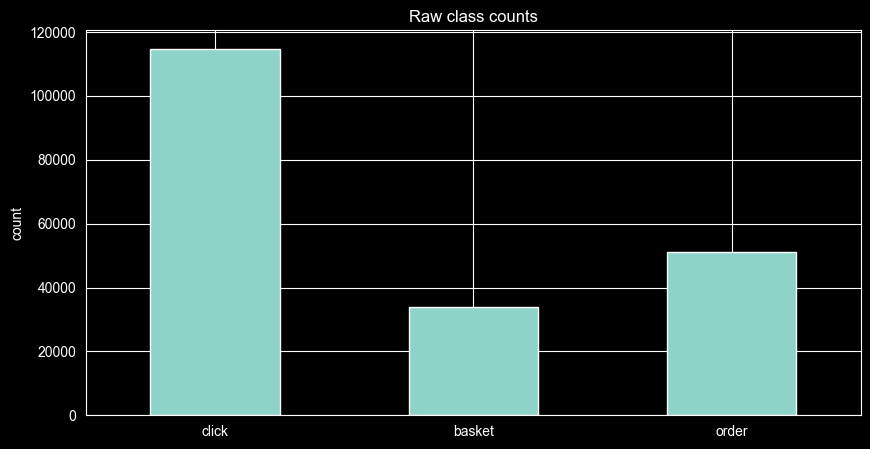

In [9]:
target_cols = ["click", "basket", "order"]

class_balance = (
    df[target_cols]
    .sum()
    .rename("count")
    .to_frame()
)

class_balance["share"] = class_balance["count"] / len(df)
display(class_balance)

ax = class_balance["count"].plot(kind="bar")
ax.set_title("Raw class counts")
ax.set_ylabel("count")
plt.xticks(rotation=0)
plt.show()


In [11]:
df["action_sum"] = df[target_cols].sum(axis=1)

action_sum_check = df["action_sum"].value_counts().sort_index().rename_axis("sum_of_one_hot").to_frame("rows")
display(action_sum_check)

if not df["action_sum"].eq(1).all():
    bad_rows = df.loc[~df["action_sum"].eq(1), ["lineID", "day", "pid"] + target_cols].head(10)
    raise ValueError("Some rows do not have exactly one final action. Inspect bad_rows below.\n\n" + str(bad_rows))

df["action"] = df[target_cols].idxmax(axis=1)
df = df.drop(columns=["action_sum"])

print(df["action"].value_counts(dropna=False))
print(df["action"].unique())


,rows
sum_of_one_hot,
1,200000


action
click     114808
order      51171
basket     34021
Name: count, dtype: int64
<StringArray>
['click', 'order', 'basket']
Length: 3, dtype: str


## 2) Feature cleaning and leakage control

In [13]:
# Add simple time features from the observed day index
# We do not have real calendar dates, so these are derived calendar proxies.

df["weekday"] = ((df["day"] - 1) % 7) + 1
df["week_idx"] = ((df["day"] - 1) // 7) + 1
df["month_idx"] = ((df["day"] - 1) // 30) + 1

# Treat coded category-like columns as categorical
categorical_candidates = ["manufacturer", "group", "unit", "pharmForm", "category"]
for col in categorical_candidates:
    if col in df.columns:
        df[col] = df[col].astype(object)
        df[col] = df[col].where(pd.notna(df[col]), np.nan)

# Replace infinities if any appear
df = df.replace([np.inf, -np.inf], np.nan)

# Columns to exclude from predictors
drop_cols = [
    "action",      # final target
    "click",       # direct leakage
    "basket",      # direct leakage
    "order",       # direct leakage
    "revenue",     # post-outcome information
    "lineID",      # identifier
    "pid",         # identifier / memorization risk
]

feature_cols = [c for c in df.columns if c not in drop_cols]
X_full = df[feature_cols].copy()
y_full = df["action"].copy()

numeric_cols = [c for c in X_full.columns if pd.api.types.is_numeric_dtype(X_full[c])]
categorical_cols = [c for c in X_full.columns if c not in numeric_cols]

print("Numeric features:", len(numeric_cols))
print(numeric_cols)
print()
print("Categorical features:", len(categorical_cols))
print(categorical_cols)


Numeric features: 21
['day', 'adFlag', 'availability', 'competitorPrice', 'price', 'content', 'genericProduct', 'salesIndex', 'rrp', 'has_competitor', 'campaignIndex_A', 'campaignIndex_B', 'campaignIndex_C', 'price_diff_competitor', 'price_ratio_competitor', 'price_pct_diff_competitor', 'is_post_shift_day', 'price_diff_vs_previous_available_day', 'weekday', 'week_idx', 'month_idx']

Categorical features: 5
['manufacturer', 'group', 'unit', 'pharmForm', 'category']


## 3) Target behavior across time

action,day,basket,click,order
0,1,326,521,483
1,2,310,482,432
2,3,464,675,690
3,4,451,634,727
4,5,461,746,698


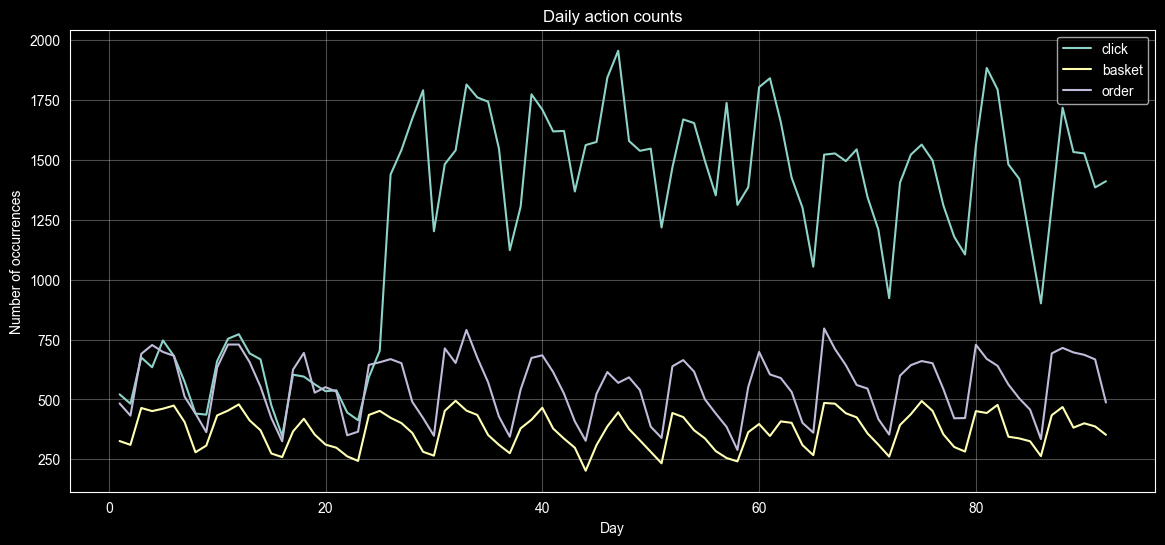

In [18]:
daily_action_counts = (
    df.groupby(["day", "action"])
      .size()
      .unstack(fill_value=0)
      .reset_index()
)

display(daily_action_counts.head())

plt.figure(figsize=(14, 6))
for action in ["click", "basket", "order"]:
    if action in daily_action_counts.columns:
        plt.plot(daily_action_counts["day"], daily_action_counts[action], label=action)

plt.title("Daily action counts")
plt.xlabel("Day")
plt.ylabel("Number of occurrences")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


This plot shows clear weekly seasonality in customer actions.
Click is considerably increased in counts after day 25/26 due to the advertisement,
but the increased level of traffic(clicks) does nto seem to influence the levels of order.

weekday
1    5910
2    4602
3    8373
4    8843
5    8525
6    7967
7    6951
dtype: int64

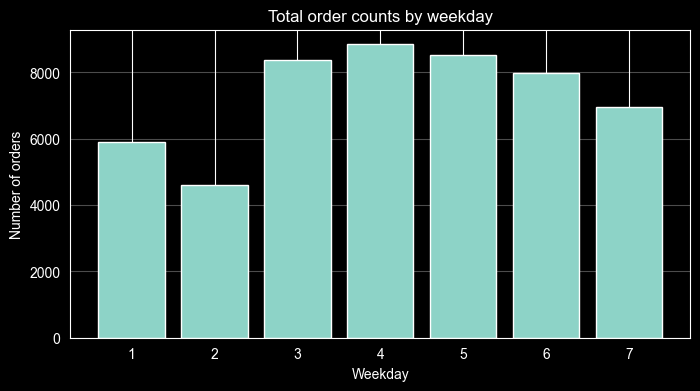

In [19]:
order_by_weekday = (
    df[df["action"] == "order"]
    .groupby("weekday")
    .size()
    .reindex(range(1, 8), fill_value=0)
)

display(order_by_weekday)

plt.figure(figsize=(8, 4))
plt.bar(order_by_weekday.index, order_by_weekday.values)
plt.title("Total order counts by weekday")
plt.xlabel("Weekday")
plt.ylabel("Number of orders")
plt.xticks(range(1, 8))
plt.grid(True, axis="y", alpha=0.3)
plt.show()

This chart shows that order counts are not evenly distributed across the week.
Orders are lowest on weekday 2 and highest around weekdays 4 and 5, which suggests that customer purchasing behavior depends on the day of the week.
This supports the earlier observation that order activity follows a clear weekly seasonal pattern.

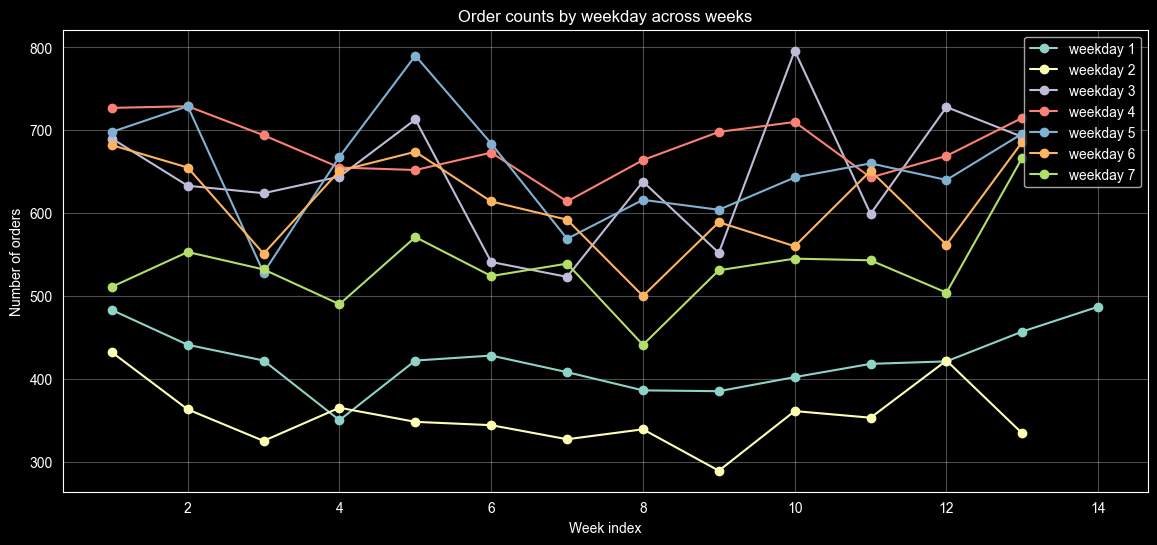

In [20]:
order_weekday_week = (
    df[df["action"] == "order"]
    .groupby(["week_idx", "weekday"])
    .size()
    .reset_index(name="order_count")
)

plt.figure(figsize=(14, 6))
for wd in range(1, 8):
    subset = order_weekday_week[order_weekday_week["weekday"] == wd]
    plt.plot(subset["week_idx"], subset["order_count"], marker="o", label=f"weekday {wd}")

plt.title("Order counts by weekday across weeks")
plt.xlabel("Week index")
plt.ylabel("Number of orders")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

This plot shows that the weekday pattern repeats across most weeks, which further confirms weekly seasonality in order behavior.
The same weekdays tend to stay relatively high or low over time, even though the exact order counts still fluctuate from week to week.
This means the day of the week is an important signal for predicting customer orders.

1     0.427648
2    -0.170967
3    -0.500441
4    -0.541155
5    -0.266763
6     0.362760
7     0.827207
8     0.375227
9    -0.192798
10   -0.515355
11   -0.548807
12   -0.252634
13    0.372298
14    0.822065
15    0.332856
16   -0.259163
17   -0.553106
18   -0.550470
19   -0.249840
20    0.340469
21    0.808964
Name: autocorrelation, dtype: float64


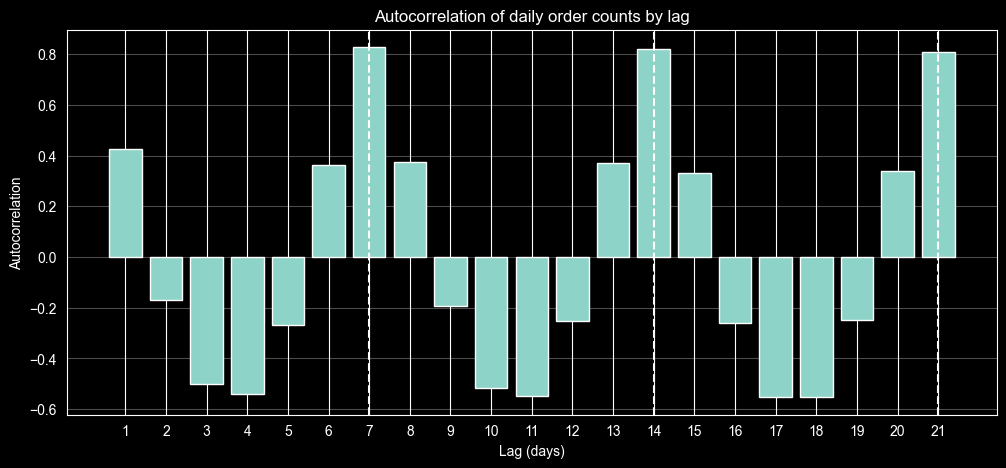

In [26]:
daily_orders = (
    df[df["action"] == "order"]
    .groupby("day")
    .size()
    .reindex(range(df["day"].min(), df["day"].max() + 1), fill_value=0)
)

lag_corrs = pd.Series(
    {lag: daily_orders.autocorr(lag=lag) for lag in range(1, 22)},
    name="autocorrelation"
)

plt.figure(figsize=(12, 5))
plt.bar(lag_corrs.index, lag_corrs.values)
plt.axvline(7, linestyle="--")
plt.axvline(14, linestyle="--")
plt.axvline(21, linestyle="--")
plt.title("Autocorrelation of daily order counts by lag")
plt.xlabel("Lag (days)")
plt.ylabel("Autocorrelation")
plt.xticks(range(1, 22))
plt.grid(True, axis="y", alpha=0.3)
plt.show()

This autocorrelation plot confirms strong weekly seasonality in order counts.
The highest positive correlations appear at lags 7, 14, and 21, which means order behavior tends to repeat every 7 days.
This provides statistical support for the visual patterns observed in the earlier time series and weekday plots.

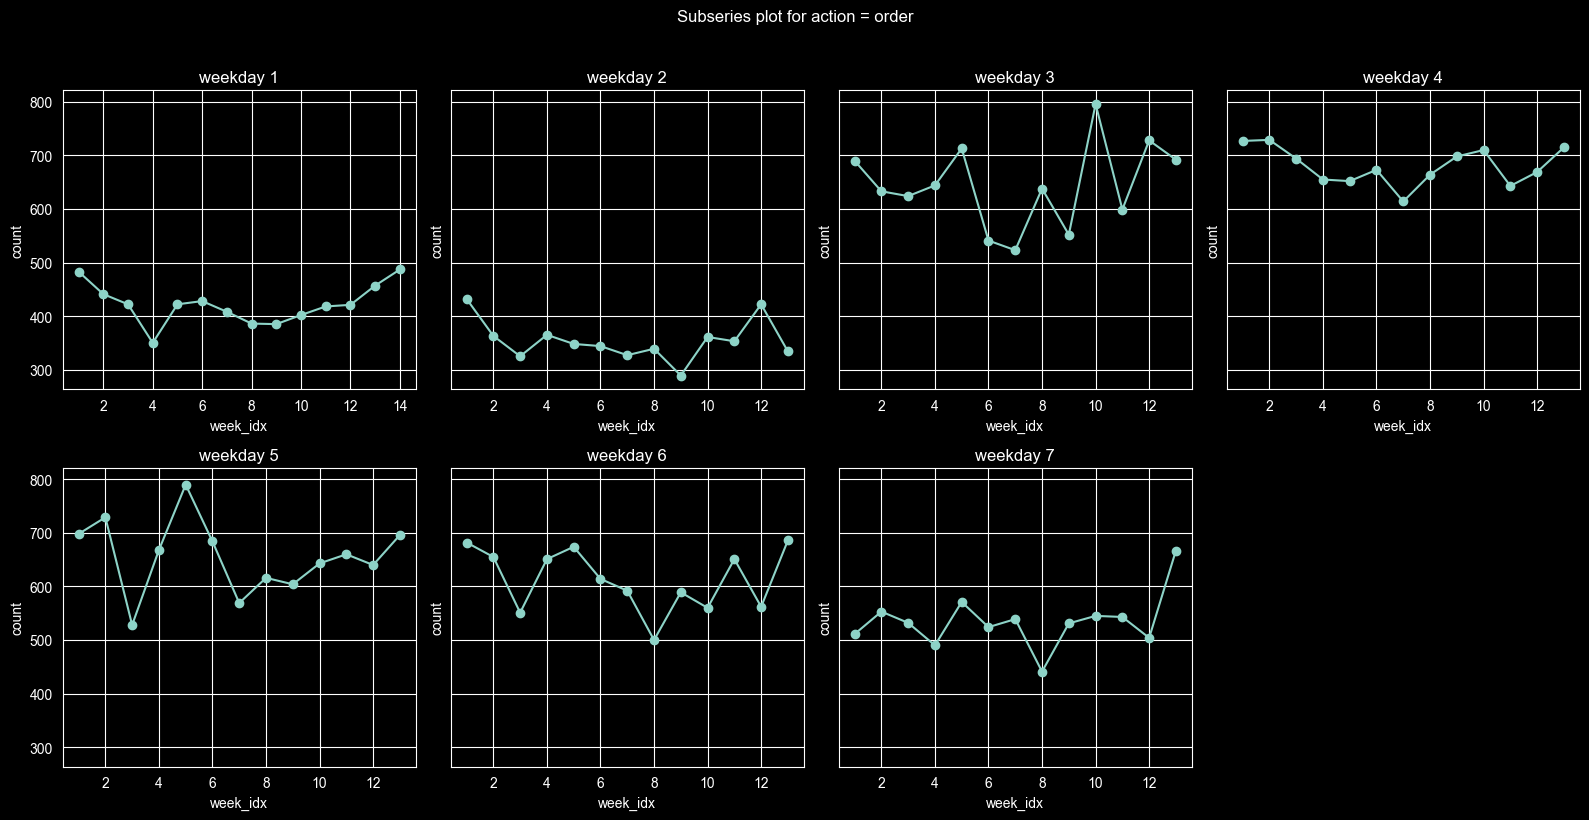

In [28]:
# Subseries plot:
# for each weekday, show the week-by-week COUNT of the selected action

selected_action = "order"

plot_df = (
    df[df["action"] == selected_action]
    .groupby(["week_idx", "weekday"])
    .size()
    .reset_index(name="count")
)

fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey=True)
axes = axes.ravel()

for weekday in sorted(plot_df["weekday"].unique()):
    ax = axes[weekday - 1]
    sub = plot_df.loc[plot_df["weekday"] == weekday].sort_values("week_idx")
    ax.plot(sub["week_idx"], sub["count"], marker="o")
    ax.set_title(f"weekday {weekday}")
    ax.set_xlabel("week_idx")
    ax.set_ylabel("count")

# remove the unused 8th panel
fig.delaxes(axes[-1])

fig.suptitle(f"Subseries plot for action = {selected_action}", y=1.02)
plt.tight_layout()
plt.show()

This subseries plot confirms that the weekly order pattern stays visible even in absolute counts.
Some weekdays, especially weekdays 3 to 6, consistently have higher order volumes, while weekdays 1, 2, and 7 are generally lower.
This plot shows that order counts themselves remain fairly stable over time, so the main effect of the advertisement was increased traffic rather than a strong increase in purchases.

## 4) Build modeling sample and split chronologically

In [29]:
model_df = df.copy()

X = model_df[feature_cols].copy()
y = model_df["action"].copy()

# protect object columns from pandas NA issues inside sklearn pipelines
for col in X.columns:
    if X[col].dtype == object:
        X[col] = X[col].where(pd.notna(X[col]), np.nan)

unique_days = np.sort(model_df["day"].unique())
split_idx = int(len(unique_days) * 0.80)

train_days = unique_days[:split_idx]
test_days = unique_days[split_idx:]

train_mask = model_df["day"].isin(train_days)
test_mask = model_df["day"].isin(test_days)

X_train = X.loc[train_mask].copy()
X_test = X.loc[test_mask].copy()
y_train = y.loc[train_mask].copy()
y_test = y.loc[test_mask].copy()

print("Train days:", train_days.min(), "to", train_days.max())
print("Test days :", test_days.min(), "to", test_days.max())
print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

display(pd.DataFrame({
    "train_share": y_train.value_counts(normalize=True).sort_index(),
    "test_share": y_test.value_counts(normalize=True).sort_index(),
}).fillna(0))

Train days: 1 to 73
Test days : 74 to 92
Train shape: (154176, 26)
Test shape : (45824, 26)


,train_share,test_share
action,,
basket,0.172777,0.161116
click,0.567819,0.594972
order,0.259405,0.243911


## 5) Helper functions

In [30]:
def make_results_row(model_name, y_true, y_pred, y_proba, class_labels):
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
        "log_loss": log_loss(y_true, y_proba, labels=class_labels),
    }


def show_confusion_matrix(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_df = pd.DataFrame(cm, index=[f"true_{x}" for x in labels], columns=[f"pred_{x}" for x in labels])
    display(cm_df)

    plt.figure(figsize=(6, 4))
    plt.imshow(cm, aspect="auto")
    plt.xticks(range(len(labels)), labels)
    plt.yticks(range(len(labels)), labels)
    plt.title(title)
    plt.xlabel("predicted")
    plt.ylabel("true")
    plt.colorbar()
    plt.show()


def top_permutation_importance(model, X_eval, y_eval, scoring="f1_macro", top_n=12):
    perm = permutation_importance(
        model,
        X_eval,
        y_eval,
        scoring=scoring,
        n_repeats=5,
        random_state=RANDOM_STATE,
    )
    imp = (
        pd.Series(perm.importances_mean, index=X_eval.columns)
        .sort_values(ascending=False)
        .head(top_n)
        .rename("importance")
        .to_frame()
    )
    return imp


## 6) Model 1: multinomial logistic regression baseline

In [31]:
baseline_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            numeric_cols,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("ohe", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=0.01)),
            ]),
            categorical_cols,
        ),
    ]
)

logreg_model = Pipeline([
    ("preprocess", baseline_preprocessor),
    ("model", LogisticRegression(max_iter=200, class_weight="balanced")),
])

logreg_model.fit(X_train, y_train)

logreg_pred = logreg_model.predict(X_test)
logreg_proba = logreg_model.predict_proba(X_test)

logreg_results = make_results_row(
    "multinomial_logistic_regression",
    y_test,
    logreg_pred,
    logreg_proba,
    logreg_model.classes_,
)

display(pd.DataFrame(classification_report(y_test, logreg_pred, output_dict=True)).T)


,precision,recall,f1-score,support
basket,0.350532,0.183123,0.240569,7383.000000
click,0.677964,0.747616,0.711089,27264.000000
order,0.355318,0.378366,0.366480,11177.000000
accuracy,0.566603,0.566603,0.566603,0.566603
macro avg,0.461271,0.436369,0.439379,45824.000000
weighted avg,0.546513,0.566603,0.551226,45824.000000


## 7) Model 2: shallow decision tree

In [32]:
tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
            ]),
            numeric_cols,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("ohe", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=0.01)),
            ]),
            categorical_cols,
        ),
    ]
)

tree_model = Pipeline([
    ("preprocess", tree_preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=TREE_MAX_DEPTH,
        min_samples_leaf=TREE_MIN_SAMPLES_LEAF,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )),
])

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)
tree_proba = tree_model.predict_proba(X_test)

tree_results = make_results_row(
    "shallow_decision_tree",
    y_test,
    tree_pred,
    tree_proba,
    tree_model.classes_,
)

display(pd.DataFrame(classification_report(y_test, tree_pred, output_dict=True)).T)


,precision,recall,f1-score,support
basket,0.915276,0.096573,0.174712,7383.000000
click,0.650179,0.826841,0.727945,27264.000000
order,0.353418,0.327995,0.340232,11177.000000
accuracy,0.587509,0.587509,0.587509,0.587509
macro avg,0.639624,0.417136,0.414296,45824.000000
weighted avg,0.620507,0.587509,0.544242,45824.000000


## 8) Model 3: GAM-like additive spline logistic model

A true GAM library is not available here, so this uses a **GAM-like additive setup**:
- spline basis expansion for selected numeric variables
- linear terms for the remaining numeric variables
- one-hot encoded categorical variables
- multinomial logistic regression on top

This keeps the model more interpretable than a black-box ensemble while still allowing smooth non-linear effects.


In [33]:
spline_features = [
    c for c in [
        "price",
        "competitorPrice",
        "rrp",
        "price_diff_competitor",
        "price_ratio_competitor",
        "price_pct_diff_competitor",
        "price_diff_vs_previous_available_day",
    ]
    if c in numeric_cols
]

linear_numeric_features = [c for c in numeric_cols if c not in spline_features]

spline_preprocessor = ColumnTransformer(
    transformers=[
        (
            "linear_num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            linear_numeric_features,
        ),
        (
            "spline_num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("spline", SplineTransformer(n_knots=5, degree=3, include_bias=False)),
                ("scaler", StandardScaler(with_mean=False)),
            ]),
            spline_features,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("ohe", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=0.02)),
            ]),
            categorical_cols,
        ),
    ]
)

spline_model = Pipeline([
    ("preprocess", spline_preprocessor),
    ("model", LogisticRegression(max_iter=200)),
])

spline_model.fit(X_train, y_train)

spline_pred = spline_model.predict(X_test)
spline_proba = spline_model.predict_proba(X_test)

spline_results = make_results_row(
    "gam_like_additive_spline_logit",
    y_test,
    spline_pred,
    spline_proba,
    spline_model.classes_,
)

display(pd.DataFrame(classification_report(y_test, spline_pred, output_dict=True)).T)


,precision,recall,f1-score,support
basket,0.857820,0.098063,0.176006,7383.000000
click,0.621632,0.967173,0.756827,27264.000000
order,0.434205,0.099490,0.161887,11177.000000
accuracy,0.615507,0.615507,0.615507,0.615507
macro avg,0.637886,0.388242,0.364907,45824.000000
weighted avg,0.613970,0.615507,0.518135,45824.000000


## 9) Compare models

In [34]:
results_df = pd.DataFrame([
    logreg_results,
    tree_results,
    spline_results,
]).sort_values(["macro_f1", "balanced_accuracy", "weighted_f1"], ascending=False).reset_index(drop=True)

display(results_df.round(4))

best_model_name = results_df.loc[0, "model"]
print("Best model by macro_f1:", best_model_name)


,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,log_loss
0,multinomial_logistic_regression,0.5666,0.4364,0.4394,0.5512,0.9771
1,shallow_decision_tree,0.5875,0.4171,0.4143,0.5442,0.9916
2,gam_like_additive_spline_logit,0.6155,0.3882,0.3649,0.5181,0.8911


Best model by macro_f1: multinomial_logistic_regression



multinomial_logistic_regression


,pred_click,pred_basket,pred_order
true_click,20383,1471,5410
true_basket,3768,1352,2263
true_order,5914,1034,4229


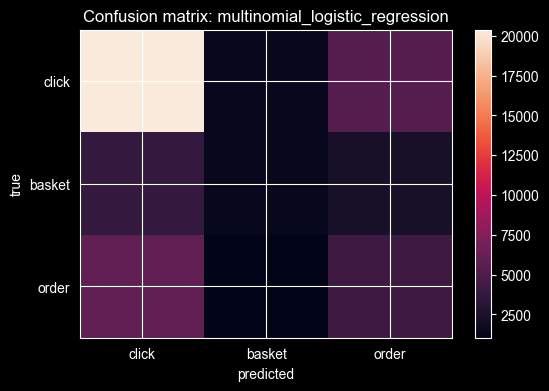


shallow_decision_tree


,pred_click,pred_basket,pred_order
true_click,22543,37,4684
true_basket,4647,713,2023
true_order,7482,29,3666


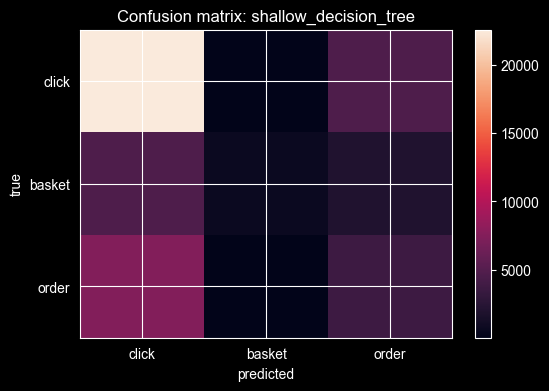


gam_like_additive_spline_logit


,pred_click,pred_basket,pred_order
true_click,26369,66,829
true_basket,6039,724,620
true_order,10011,54,1112


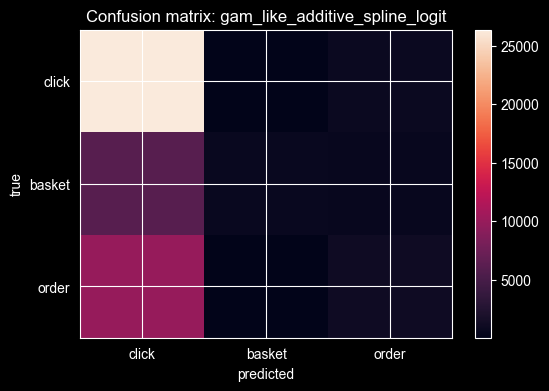

In [35]:
models = {
    "multinomial_logistic_regression": (logreg_model, logreg_pred),
    "shallow_decision_tree": (tree_model, tree_pred),
    "gam_like_additive_spline_logit": (spline_model, spline_pred),
}

for model_name, (model_obj, preds) in models.items():
    print("\n" + "=" * 80)
    print(model_name)
    show_confusion_matrix(y_test, preds, labels=["click", "basket", "order"], title=f"Confusion matrix: {model_name}")


## 10) Inspect explanations

,coefficient
cat__group_1COS2,-1.567977
cat__group_1COI00OT,0.492920
cat__category_101.0,-0.239343
cat__group_22OI2,0.238162
num__price,-0.221019
cat__category_116.0,0.216969
cat__group_19OZ1ESI,0.214212
cat__manufacturer_18,-0.210620
cat__category_71.0,0.186471
cat__category_73.0,0.184201


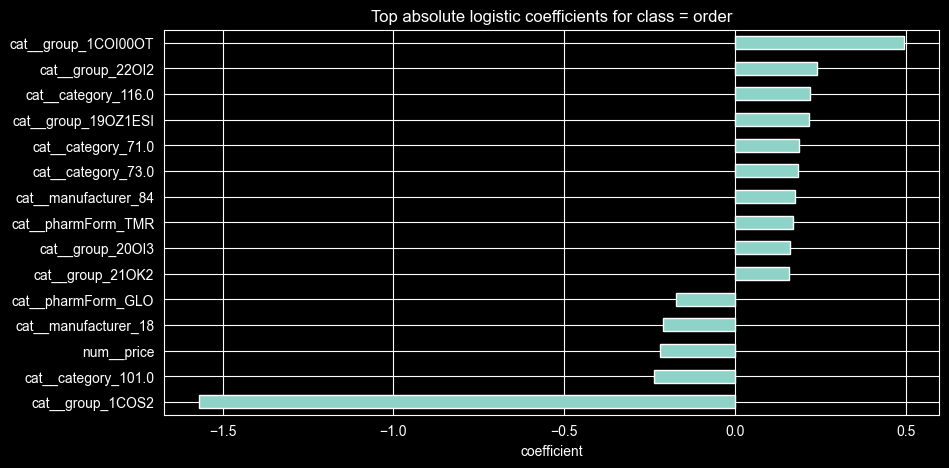

In [41]:
# 10a) Logistic regression coefficients for the ORDER class

logreg_feature_names = logreg_model.named_steps["preprocess"].get_feature_names_out()
logreg_coef_df = pd.DataFrame(
    logreg_model.named_steps["model"].coef_,
    index=logreg_model.classes_,
    columns=logreg_feature_names,
).T

order_coef = (
    logreg_coef_df["order"]
    .sort_values(key=np.abs, ascending=False)
    .head(15)
    .rename("coefficient")
    .to_frame()
)

display(order_coef)

plot_series = order_coef["coefficient"].sort_values()
plot_series.plot(kind="barh")
plt.title("Top absolute logistic coefficients for class = order")
plt.xlabel("coefficient")
plt.show()


This plot shows which features push the logistic regression model most strongly toward or away from predicting order.
Most of the strongest effects come from specific product groups, categories, manufacturers, and dosage forms, while price has a negative coefficient, meaning higher prices are associated with a lower probability of order.
The very large negative coefficient for group_1COS2 suggests that this product group is especially unlikely to end in a purchase compared with the baseline.

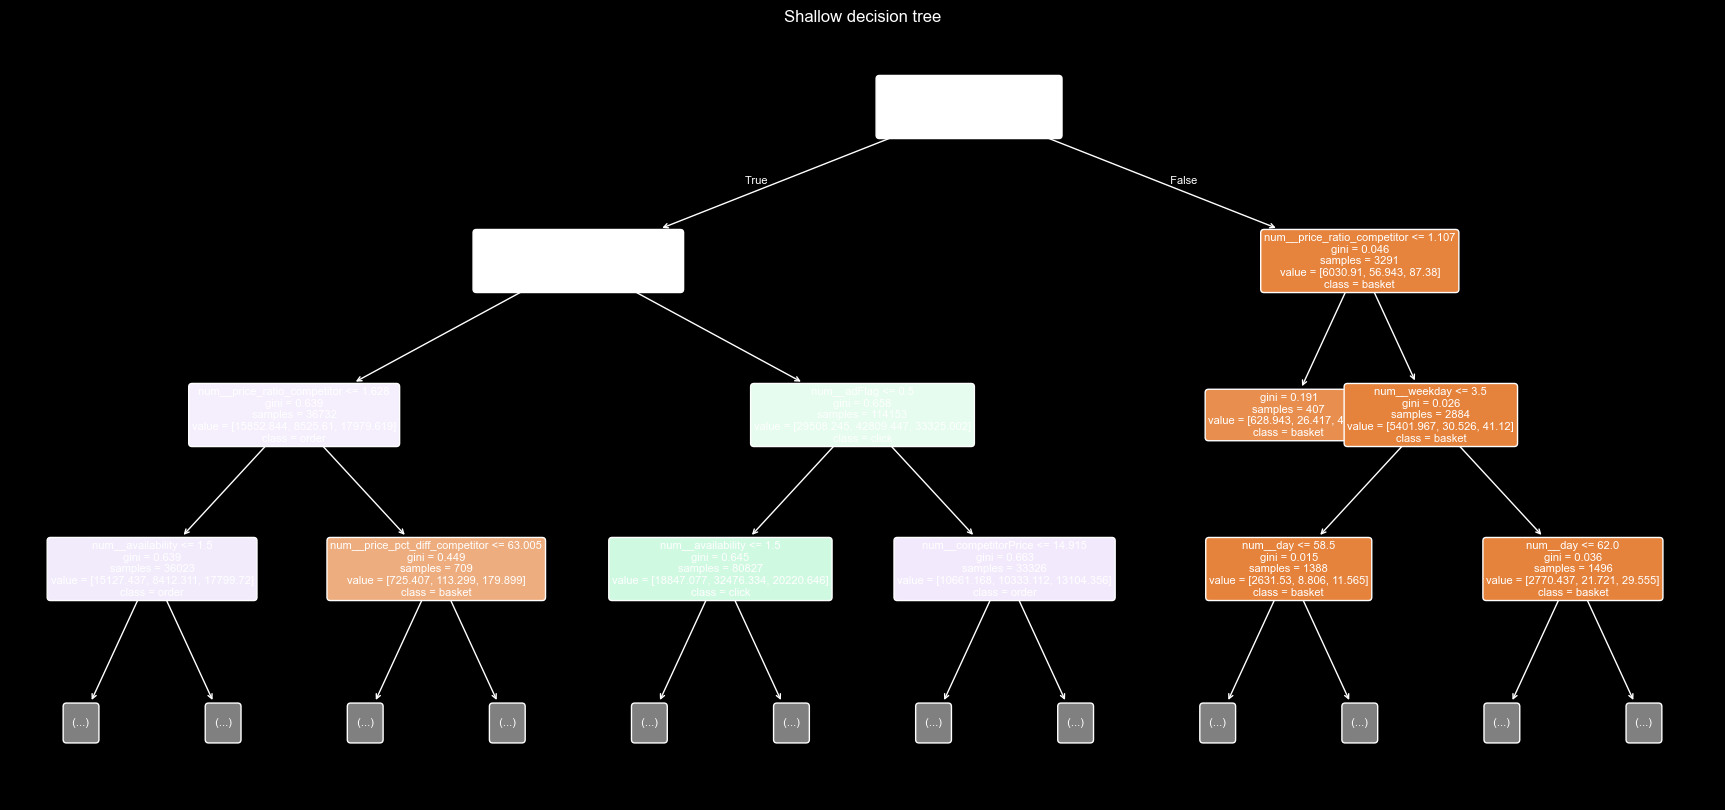

|--- group_1COS2 <= 0.50
|   |--- day <= 25.50
|   |   |--- price_ratio_competitor <= 1.63
|   |   |   |--- availability <= 1.50
|   |   |   |   |--- class: order
|   |   |   |--- availability >  1.50
|   |   |   |   |--- class: click
|   |   |--- price_ratio_competitor >  1.63
|   |   |   |--- price_pct_diff_comp <= 63.00
|   |   |   |   |--- class: basket
|   |   |   |--- price_pct_diff_comp >  63.00
|   |   |   |   |--- class: basket
|   |--- day >  25.50
|   |   |--- adFlag <= 0.50
|   |   |   |--- availability <= 1.50
|   |   |   |   |--- class: click
|   |   |   |--- availability >  1.50
|   |   |   |   |--- class: click
|   |   |--- adFlag >  0.50
|   |   |   |--- competitorPrice <= 14.91
|   |   |   |   |--- class: order
|   |   |   |--- competitorPrice >  14.91
|   |   |   |   |--- class: click
|--- group_1COS2 >  0.50
|   |--- price_ratio_competitor <= 1.11
|   |   |--- class: basket
|   |--- price_ratio_competitor >  1.11
|   |   |--- weekday <= 3.50
|   |   |   |--- day <= 

In [44]:
# 10b) Shallow decision tree structure

tree_feature_names = tree_model.named_steps["preprocess"].get_feature_names_out()
tree_estimator = tree_model.named_steps["model"]

plt.figure(figsize=(22, 10))
plot_tree(
    tree_estimator,
    feature_names=tree_feature_names,
    class_names=tree_model.classes_,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8,
)
plt.title("Shallow decision tree")
plt.show()

# not readable trying to print the text instead
from sklearn.tree import export_text

tree_feature_names = tree_model.named_steps["preprocess"].get_feature_names_out()
tree_estimator = tree_model.named_steps["model"]

short_feature_names = [
    name.replace("num__", "")
        .replace("cat__", "")
        .replace("price_pct_diff_competitor", "price_pct_diff_comp")
        .replace("price_diff_vs_previous_available_day", "price_diff_prev_day")
        .replace("campaignIndex_", "camp_")
    for name in tree_feature_names
]

tree_rules = export_text(
    tree_estimator,
    feature_names=short_feature_names
)

print(tree_rules)

The tree is very shallow and relies on only a few features, mainly group_1COS2, day, price_ratio_competitor, availability, adFlag, and competitorPrice.
It separates some order cases, but many terminal nodes still predict click or basket, which shows the model struggles to capture more detailed order behavior.
The early split on day also suggests that the time period, especially before vs. after day 25, is an important factor in customer actions.

How to improve the next tree:
Allow a slightly deeper tree, because this one is probably too simple.
Handle class imbalance more explicitly, for example with class_weight="balanced".
Tune key parameters such as max_depth, min_samples_leaf, and min_samples_split.
Try stronger time features and cleaner price-related features, since these seem important in the current tree.

,importance
group,0.044540
price,0.023993
adFlag,0.009433
manufacturer,0.007038
rrp,0.006765
pharmForm,0.005686
category,0.005112
price_diff_competitor,0.003027
availability,0.002815
unit,0.001180


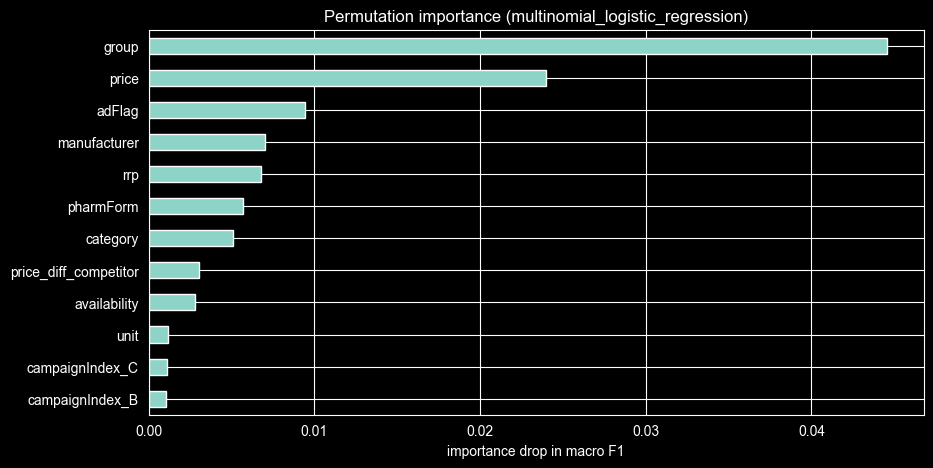

In [39]:
# 10c) Permutation importance for the best model

best_model = {
    "multinomial_logistic_regression": logreg_model,
    "shallow_decision_tree": tree_model,
    "gam_like_additive_spline_logit": spline_model,
}[best_model_name]

best_importance = top_permutation_importance(best_model, X_test, y_test, scoring="f1_macro", top_n=12)
display(best_importance)

best_importance["importance"].sort_values().plot(kind="barh")
plt.title(f"Permutation importance ({best_model_name})")
plt.xlabel("importance drop in macro F1")
plt.show()


This shows that group is the most important feature for the logistic regression model by a clear margin, with price as the second most important predictor.
adFlag, manufacturer, rrp, pharmForm, and category have some additional influence, but much smaller than group and price.
The very low importance of the remaining features means that shuffling them barely changes macro F1, so they contribute little to the model’s overall classification performance.

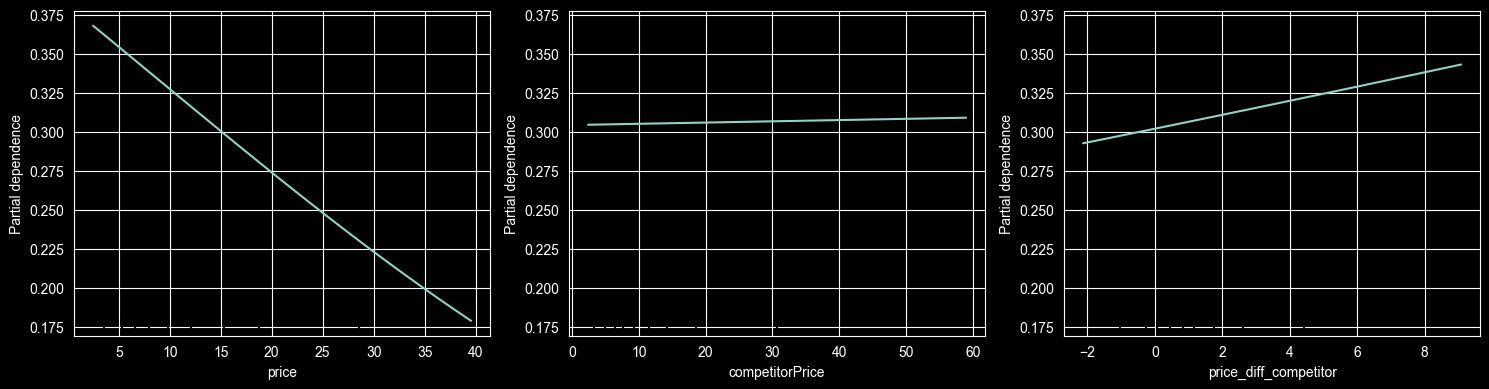

In [45]:
# 10d) Partial dependence for a few numeric features on P(order)

candidate_pdp_features = [c for c in ["price", "competitorPrice", "price_diff_competitor", "availability"] if c in X_test.columns]
candidate_pdp_features = candidate_pdp_features[:3]

if candidate_pdp_features:
    fig, ax = plt.subplots(1, len(candidate_pdp_features), figsize=(5 * len(candidate_pdp_features), 4))
    if len(candidate_pdp_features) == 1:
        ax = [ax]

    PartialDependenceDisplay.from_estimator(
        best_model,
        X_test,
        features=candidate_pdp_features,
        target="order",
        ax=ax,
    )
    plt.tight_layout()
    plt.show()
else:
    print("No numeric features available for partial dependence.")


## 11) Final short summary

In [47]:
summary_row = results_df.iloc[0]

print(f"Best interpretable model: {summary_row['model']}")
print(f"Accuracy: {summary_row['accuracy']:.4f}")
print(f"Balanced accuracy: {summary_row['balanced_accuracy']:.4f}")
print(f"Macro F1: {summary_row['macro_f1']:.4f}")
print(f"Weighted F1: {summary_row['weighted_f1']:.4f}")
print(f"Log loss: {summary_row['log_loss']:.4f}")


Best interpretable model: multinomial_logistic_regression
Accuracy: 0.5666
Balanced accuracy: 0.4364
Macro F1: 0.4394
Weighted F1: 0.5512
Log loss: 0.9771


## 12) Balance training data and prepare improved training set

In [48]:
from sklearn.utils import resample

train_df = X_train.copy()
train_df["action"] = y_train.values

class_counts_before = train_df["action"].value_counts().sort_index()
display(class_counts_before.rename("count_before").to_frame())

max_count = train_df["action"].value_counts().max()

balanced_parts = []
for cls in sorted(train_df["action"].unique()):
    cls_df = train_df[train_df["action"] == cls]
    cls_balanced = resample(
        cls_df,
        replace=True,
        n_samples=max_count,
        random_state=RANDOM_STATE
    )
    balanced_parts.append(cls_balanced)

train_balanced_df = (
    pd.concat(balanced_parts, axis=0)
    .sample(frac=1, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

X_train_bal = train_balanced_df.drop(columns="action").copy()
y_train_bal = train_balanced_df["action"].copy()

class_counts_after = y_train_bal.value_counts().sort_index()
display(class_counts_after.rename("count_after").to_frame())

print("Original train shape :", X_train.shape)
print("Balanced train shape :", X_train_bal.shape)
print("Test shape remains   :", X_test.shape)

,count_before
action,
basket,26638
click,87544
order,39994


,count_after
action,
basket,87544
click,87544
order,87544


Original train shape : (154176, 26)
Balanced train shape : (262632, 26)
Test shape remains   : (45824, 26)


## 13) Retrain improved multinomial logistic regression

In [52]:
baseline_preprocessor_improved = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            numeric_cols,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("ohe", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=0.01)),
            ]),
            categorical_cols,
        ),
    ]
)

logreg_model_improved = Pipeline([
    ("preprocess", baseline_preprocessor_improved),
    ("model", LogisticRegression(
        max_iter=2000
    )),
])

logreg_model_improved.fit(X_train_bal, y_train_bal)

logreg_pred_improved = logreg_model_improved.predict(X_test)
logreg_proba_improved = logreg_model_improved.predict_proba(X_test)

logreg_results_improved = make_results_row(
    "multinomial_logistic_regression_improved",
    y_test,
    logreg_pred_improved,
    logreg_proba_improved,
    logreg_model_improved.classes_,
)
print(logreg_model_improved.named_steps["model"].n_iter_)
display(pd.DataFrame(classification_report(y_test, logreg_pred_improved, output_dict=True)).T)

[106]


,precision,recall,f1-score,support
basket,0.351090,0.196397,0.251889,7383.000000
click,0.679163,0.745525,0.710799,27264.000000
order,0.354581,0.373267,0.363684,11177.000000
accuracy,0.566253,0.566253,0.566253,0.566253
macro avg,0.461611,0.438396,0.442124,45824.000000
weighted avg,0.547136,0.566253,0.552196,45824.000000


Balancing the training data improved the results only slightly, so class imbalance was not the main reason for weak performance.
The model still predicts click much better than basket and order, which suggests that final purchase behavior is harder to explain with the current features.
From the model and earlier plots, we can learn that product group, price, and time-related patterns matter, but the advertisement seems to increase clicks much more than actual orders.

## 14) Improved decision tree

In [61]:
tree_model_improved = Pipeline([
    ("preprocess", baseline_preprocessor_improved),
    ("model", DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=50,
        class_weight={"click": 1.0, "basket": 1.2, "order": 1.3},
        random_state=RANDOM_STATE,
    )),
])

tree_model_improved.fit(X_train_bal, y_train_bal)

tree_pred_improved = tree_model_improved.predict(X_test)
tree_proba_improved = tree_model_improved.predict_proba(X_test)

tree_results_improved = make_results_row(
    "decision_tree_improved",
    y_test,
    tree_pred_improved,
    tree_proba_improved,
    tree_model_improved.classes_,
)

display(pd.DataFrame(classification_report(y_test, tree_pred_improved, output_dict=True)).T)

,precision,recall,f1-score,support
basket,0.970994,0.095219,0.173430,7383.000000
click,0.676331,0.680201,0.678261,27264.000000
order,0.325566,0.514986,0.398933,11177.000000
accuracy,0.545653,0.545653,0.545653,0.545653
macro avg,0.657630,0.430135,0.416875,45824.000000
weighted avg,0.638251,0.545653,0.528793,45824.000000


In [62]:
from sklearn.tree import export_text

tree_estimator = tree_model_improved.named_steps["model"]
tree_feature_names = tree_model_improved.named_steps["preprocess"].get_feature_names_out()

short_feature_names = [
    name.replace("num__", "")
        .replace("cat__", "")
        .replace("price_pct_diff_competitor", "price_pct_diff_comp")
        .replace("price_diff_vs_previous_available_day", "price_diff_prev_day")
        .replace("campaignIndex_", "camp_")
    for name in tree_feature_names
]

tree_rules = export_text(
    tree_estimator,
    feature_names=short_feature_names
)

print(tree_rules)

|--- group_1COS2 <= 0.50
|   |--- is_post_shift_day <= -0.46
|   |   |--- price_pct_diff_comp <= 2.87
|   |   |   |--- availability <= 1.19
|   |   |   |   |--- genericProduct <= 1.13
|   |   |   |   |   |--- class: order
|   |   |   |   |--- genericProduct >  1.13
|   |   |   |   |   |--- class: order
|   |   |   |--- availability >  1.19
|   |   |   |   |--- price <= -0.14
|   |   |   |   |   |--- class: order
|   |   |   |   |--- price >  -0.14
|   |   |   |   |   |--- class: click
|   |   |--- price_pct_diff_comp >  2.87
|   |   |   |--- price_ratio_competitor <= 2.88
|   |   |   |   |--- day <= -1.36
|   |   |   |   |   |--- class: basket
|   |   |   |   |--- day >  -1.36
|   |   |   |   |   |--- class: basket
|   |   |   |--- price_ratio_competitor >  2.88
|   |   |   |   |--- rrp <= 0.18
|   |   |   |   |   |--- class: order
|   |   |   |   |--- rrp >  0.18
|   |   |   |   |   |--- class: click
|   |--- is_post_shift_day >  -0.46
|   |   |--- adFlag <= 0.29
|   |   |   |--- avai

Main things to extract:

The first and strongest split is group_1COS2, so that product group is a major separator of behavior.
For products outside 1COS2, the tree mainly uses is_post_shift_day, adFlag, availability, competitorPrice, price, and competitor-relative price features to decide between order and click.
For products inside 1COS2, the logic is much simpler and often ends in basket or order, using mostly content, day, and weekday.

Important caution:
The thresholds like -0.46, 1.27, -0.14 are scaled values, not original business units, because your numeric columns were standardized before training. So the useful takeaway is which features matter and in what combination, not the raw threshold numbers themselves.

Short notebook-style observation:
The tree shows that product group is the strongest first-level driver of customer action. Outside the key 1COS2 group, order predictions are mainly influenced by timing, advertising, availability, and competitive pricing, while inside 1COS2, the model mostly separates basket and order using content and time variables. This suggests that action behavior differs strongly by product group and that order likelihood is shaped by both product identity and market conditions.

### Tree without scaled values

In [65]:
tree_preprocessor_unscaled = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
            ]),
            numeric_cols,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("ohe", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=0.01)),
            ]),
            categorical_cols,
        ),
    ]
)

tree_model_unscaled = Pipeline([
    ("preprocess", tree_preprocessor_unscaled),
    ("model", DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=50,
        class_weight={"click": 1.0, "basket": 1.2, "order": 1.3},
        random_state=RANDOM_STATE,
    )),
])

tree_model_unscaled.fit(X_train_bal, y_train_bal)

tree_pred_unscaled = tree_model_unscaled.predict(X_test)
tree_proba_unscaled = tree_model_unscaled.predict_proba(X_test)

display(pd.DataFrame(classification_report(y_test, tree_pred_unscaled, output_dict=True)).T)

tree_estimator = tree_model_unscaled.named_steps["model"]
tree_feature_names = tree_model_unscaled.named_steps["preprocess"].get_feature_names_out()

short_feature_names = [
    name.replace("num__", "").replace("cat__", "")
    for name in tree_feature_names
]

print(export_text(tree_estimator, feature_names=short_feature_names))

,precision,recall,f1-score,support
basket,0.970994,0.095219,0.173430,7383.000000
click,0.676331,0.680201,0.678261,27264.000000
order,0.325566,0.514986,0.398933,11177.000000
accuracy,0.545653,0.545653,0.545653,0.545653
macro avg,0.657630,0.430135,0.416875,45824.000000
weighted avg,0.638251,0.545653,0.528793,45824.000000


|--- group_1COS2 <= 0.50
|   |--- is_post_shift_day <= 0.50
|   |   |--- price_ratio_competitor <= 1.63
|   |   |   |--- availability <= 1.50
|   |   |   |   |--- genericProduct <= 0.50
|   |   |   |   |   |--- class: order
|   |   |   |   |--- genericProduct >  0.50
|   |   |   |   |   |--- class: order
|   |   |   |--- availability >  1.50
|   |   |   |   |--- price <= 11.31
|   |   |   |   |   |--- class: order
|   |   |   |   |--- price >  11.31
|   |   |   |   |   |--- class: click
|   |   |--- price_ratio_competitor >  1.63
|   |   |   |--- price_ratio_competitor <= 1.63
|   |   |   |   |--- day <= 10.50
|   |   |   |   |   |--- class: basket
|   |   |   |   |--- day >  10.50
|   |   |   |   |   |--- class: basket
|   |   |   |--- price_ratio_competitor >  1.63
|   |   |   |   |--- rrp <= 20.70
|   |   |   |   |   |--- class: order
|   |   |   |   |--- rrp >  20.70
|   |   |   |   |   |--- class: click
|   |--- is_post_shift_day >  0.50
|   |   |--- adFlag <= 0.50
|   |   |   |--

### Interpretation of the unscaled decision tree

The tree shows that **product group is the strongest first-level driver of customer action**, because the very first split is on `group_1COS2`. This means customer behavior differs strongly between this product group and the rest of the assortment. After that first separation, the model uses a mix of **price, competitor price, relative price to competitor, time variables, advertising, availability, and post-shift status** to decide between `order`, `click`, and `basket`.

#### What the tree suggests

- **Price matters:**
  Outside group `1COS2`, lower product price is associated with `order`, while higher price is associated more with `click`. A visible cutoff appears around **price <= 11.31**, where the model leans toward `order`, while above that threshold it leans toward `click`.

- **Competitor price matters:**
  The tree uses `competitorPrice` several times, especially in the post-shift period. This suggests that the market price level influences whether customers complete an order or only click. In some branches, orders are more likely when competitor price is relatively low, for example around **<= 4.62**, while in ad-related branches the model still predicts `order` up to about **<= 26.60** before switching more toward `click`.

- **Relative price matters:**
  `price_ratio_competitor` appears very early in the tree, which means the relationship between our price and the competitor’s price is important. This indicates that customers do not react only to the absolute price, but also to whether the product looks cheap or expensive compared with competing offers.

- **Post-shift day matters:**
  `is_post_shift_day` is the second split in the tree, making it one of the most important variables overall. This means that customer behavior changed noticeably after the shift event, and the model treats the pre-shift and post-shift periods differently.

- **Specific time matters:**
  The variables `day`, `weekday`, and `week_idx` all appear in the tree, which confirms that timing has predictive value. This supports the earlier time-series analysis showing weekly seasonality and changing behavior across the observation period.

- **Advertising matters:**
  `adFlag` appears relatively high in the tree, especially in the post-shift part. This supports the earlier observation that the advertising period affected customer behavior, even if that effect seemed stronger for clicks than for actual orders.

- **Availability matters:**
  `availability` is used several times to separate order from click behavior. In some branches, lower availability values are associated with `order`, while higher values more often lead to `click`.

- **Inside group `1COS2`:**
  For items in this specific group, the tree relies much more on **content** and **time variables** than on price. This suggests that this product group behaves differently from the rest and may follow its own purchasing pattern.

#### Main business takeaway

The tree suggests that purchase behavior is not driven by one factor alone. Instead, it depends on a combination of **product identity, pricing conditions, market context, timing, and advertising effects**. In particular, **price, competitor price, and competitor-relative price all matter**, but their influence depends on the product group and the time period.

# Next split data by group and train for each group separately

## Get dfs based on group

In [70]:
FULL_DATA_PATH = "../../../data/processed/processed_joined_dataset.csv"

# =========================
# Load full processed dataset
# =========================
df = pd.read_csv(FULL_DATA_PATH, sep="|")
print("Loaded shape:", df.shape)
print(df.columns.tolist())

# =========================
# Build / validate multiclass target
# =========================
if "action" in df.columns:
    df["action"] = df["action"].astype(object)
    print("Using existing 'action' column from processed dataset.")

elif {"click", "basket", "order"}.issubset(df.columns):
    df["action"] = np.select(
        [
            df["click"] == 1,
            df["basket"] == 1,
            df["order"] == 1,
        ],
        [
            "click",
            "basket",
            "order",
        ],
        default="unknown",
    )

    valid_action_mask = df["action"] != "unknown"
    print("Invalid target rows removed:", (~valid_action_mask).sum())
    df = df.loc[valid_action_mask].copy()

else:
    raise ValueError(
        "Dataset must contain either 'action' or all of ['click', 'basket', 'order'].\n"
        f"Available columns: {df.columns.tolist()}"
    )

# keep only rows with exactly one valid final action
valid_action_mask = df[["click", "basket", "order"]].sum(axis=1) == 1
print("Invalid target rows removed:", (~valid_action_mask).sum())
df = df.loc[valid_action_mask].copy()

# =========================
# Add simple time features
# =========================
df["weekday"] = ((df["day"] - 1) % 7) + 1
df["week_idx"] = ((df["day"] - 1) // 7) + 1
df["month_idx"] = ((df["day"] - 1) // 30) + 1

# =========================
# Treat coded category-like columns as categorical
# =========================
categorical_candidates = ["manufacturer", "group", "unit", "pharmForm", "category"]
for col in categorical_candidates:
    if col in df.columns:
        df[col] = df[col].astype(object)
        df[col] = df[col].where(pd.notna(df[col]), np.nan)

# =========================
# Replace infinities
# =========================
df = df.replace([np.inf, -np.inf], np.nan)

# =========================
# Full-model feature setup
# =========================
drop_cols = [
    "action",
    "click",
    "basket",
    "order",
    "revenue",
    "lineID",
    "pid",
]

feature_cols = [c for c in df.columns if c not in drop_cols]
X_full = df[feature_cols].copy()
y_full = df["action"].copy()

numeric_cols = [c for c in X_full.columns if pd.api.types.is_numeric_dtype(X_full[c])]
categorical_cols = [c for c in X_full.columns if c not in numeric_cols]

print("Numeric features:", len(numeric_cols))
print(numeric_cols)
print()
print("Categorical features:", len(categorical_cols))
print(categorical_cols)

# =========================
# Split into separate dataframes by product group
# =========================
df["group_split"] = df["group"].fillna("missing_group")

group_dfs = {
    grp: grp_df.copy()
    for grp, grp_df in df.groupby("group_split", sort=True)
}

group_sizes = (
    pd.Series({grp: len(grp_df) for grp, grp_df in group_dfs.items()}, name="row_count")
    .sort_values(ascending=False)
    .rename_axis("group")
    .reset_index()
)

print()
print("Number of group-specific dataframes:", len(group_dfs))
display(group_sizes)

# optional quick look at the largest groups
display(group_sizes.head(20))

# optional: access one specific group dataframe
# example:
# group_dfs["1COS2"].head()

# =========================
# Optional: prepare per-group modeling sets
# note: remove 'group' itself inside each group-specific dataset
# because it is constant within that subset
# =========================
group_model_data = {}

for grp, grp_df in group_dfs.items():
    group_feature_cols = [c for c in grp_df.columns if c not in drop_cols + ["group", "group_split"]]
    X_grp = grp_df[group_feature_cols].copy()
    y_grp = grp_df["action"].copy()

    num_grp = [c for c in X_grp.columns if pd.api.types.is_numeric_dtype(X_grp[c])]
    cat_grp = [c for c in X_grp.columns if c not in num_grp]

    group_model_data[grp] = {
        "df": grp_df,
        "X": X_grp,
        "y": y_grp,
        "numeric_cols": num_grp,
        "categorical_cols": cat_grp,
        "n_rows": len(grp_df),
    }

# optional summary of per-group model datasets
group_model_summary = pd.DataFrame([
    {
        "group": grp,
        "rows": meta["n_rows"],
        "numeric_cols": len(meta["numeric_cols"]),
        "categorical_cols": len(meta["categorical_cols"]),
    }
    for grp, meta in group_model_data.items()
]).sort_values("rows", ascending=False)

display(group_model_summary)

Loaded shape: (2755794, 29)
['lineID', 'day', 'pid', 'adFlag', 'availability', 'competitorPrice', 'click', 'basket', 'order', 'price', 'revenue', 'manufacturer', 'group', 'content', 'unit', 'pharmForm', 'genericProduct', 'salesIndex', 'category', 'rrp', 'has_competitor', 'campaignIndex_A', 'campaignIndex_B', 'campaignIndex_C', 'price_diff_competitor', 'price_ratio_competitor', 'price_pct_diff_competitor', 'is_post_shift_day', 'price_diff_vs_previous_available_day']
Invalid target rows removed: 0
Invalid target rows removed: 0
Numeric features: 21
['day', 'adFlag', 'availability', 'competitorPrice', 'price', 'content', 'genericProduct', 'salesIndex', 'rrp', 'has_competitor', 'campaignIndex_A', 'campaignIndex_B', 'campaignIndex_C', 'price_diff_competitor', 'price_ratio_competitor', 'price_pct_diff_competitor', 'is_post_shift_day', 'price_diff_vs_previous_available_day', 'weekday', 'week_idx', 'month_idx']

Categorical features: 5
['manufacturer', 'group', 'unit', 'pharmForm', 'category']

,group,row_count
0,22OI3,159787
1,2FOI,148449
2,other,137128
3,21OKG,110419
4,18OI0EOI,96243
...,...,...
228,13OI02OX,1811
229,11OK00OK,1788
230,10OZF,1757
231,1COI03OI,1741


,group,row_count
0,22OI3,159787
1,2FOI,148449
2,other,137128
3,21OKG,110419
4,18OI0EOI,96243
5,21OK3,71052
6,1COS2,55938
7,1DOIF0ZO,47419
8,18OZ00IS,46010
9,1COI00OT,44421


,group,rows,numeric_cols,categorical_cols
206,22OI3,159787,21,4
228,2FOI,148449,21,4
232,other,137128,21,4
199,21OKG,110419,21,4
104,18OI0EOI,96243,21,4
...,...,...,...,...
69,13OI02OX,1811,21,4
43,11OK00OK,1788,21,4
40,10OZF,1757,21,4
135,1COI03OI,1741,21,4
